In [ ]:
# Model : step by step development
# Algorithm : Ordered set of unimbigius (must be clear) instructions

In [ ]:
# False positive mean : the prediction made positive , how many are false predicted.
# precision : total correct prediction of true out of total positive
# Precission : actual prediction to tell positive value

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()

,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
cols = list(df.columns)
cols

['pr',
 'glucose',
 'bp_diastolic',
 'skin_triceps',
 'insulin',
 'bmi',
 'pedigree',
 'age',
 'label']

In [ ]:
df.shape

(768, 9)

In [ ]:
df.describe()

,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,label
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
lbl = "label"

In [ ]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth =3)

In [ ]:
cols.remove(lbl)
features = cols
features

['pr',
 'glucose',
 'bp_diastolic',
 'skin_triceps',
 'insulin',
 'bmi',
 'pedigree',
 'age']

In [ ]:
X = df[features]
y = df[lbl]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
model = clf.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0])

In [ ]:
df.shape[0]

768

In [ ]:
accuracy_score(y_test, y_pred)

0.7705627705627706

In [ ]:
p = precision_score(y_test, y_pred)
p

0.7105263157894737

In [ ]:
pd.Series(y_pred).value_counts()

,count
0,155
1,76


In [ ]:
matrix = confusion_matrix(y_test, y_pred)
matrix

array([[124,  22],
       [ 31,  54]])

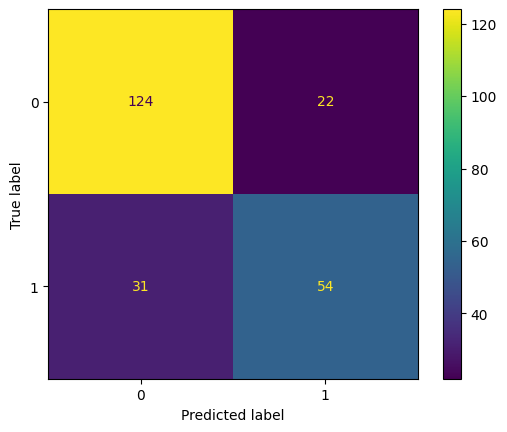

In [ ]:
disp = ConfusionMatrixDisplay(matrix)
disp.plot()
plt.show()

In [ ]:
f1_score(y_test, y_pred)

0.6708074534161491

In [ ]:
54/(31+54)

0.6352941176470588

In [ ]:
r = recall_score(y_test, y_pred)
r

0.6352941176470588

In [ ]:
2*p*r/(p+r)

0.6708074534161491

In [ ]:
print("Model Evaluation Summary")
print(f"Accuracy  : {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred)}")
print(f"Recall    : {recall_score(y_test, y_pred)}")
print(f"F1-score  : {f1_score(y_test, y_pred)}")

Model Evaluation Summary
Accuracy  : 0.7705627705627706
Precision : 0.7105263157894737
Recall    : 0.6352941176470588
F1-score  : 0.6708074534161491


In [ ]:
y = pd.DataFrame({"Original" : y_test, "Predicted" : y_pred})
y.head()

,Original,Predicted
285,0,0
101,0,0
581,0,0
352,0,0
726,0,0


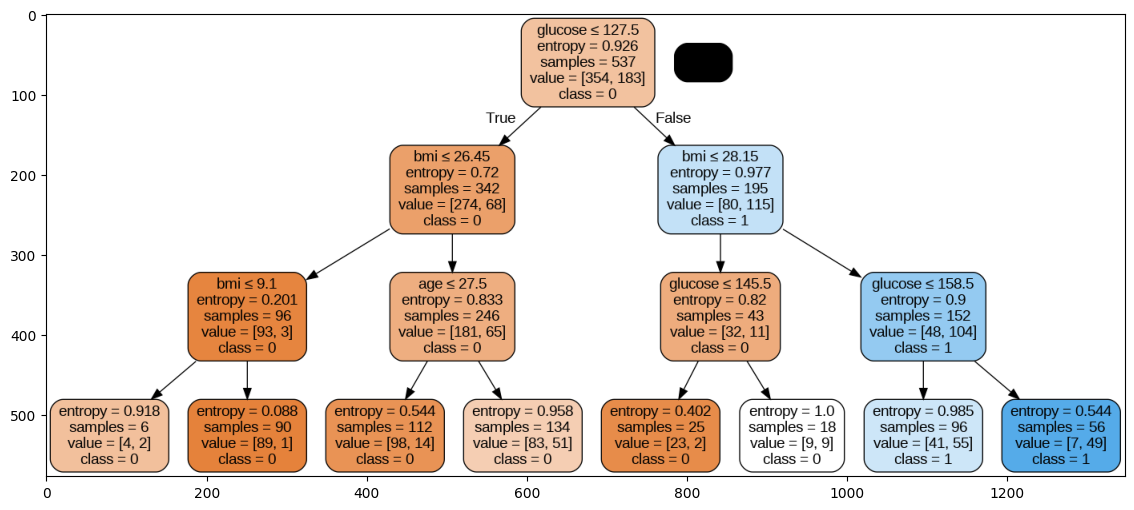

In [ ]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

imgFile = 'DecTree.png'
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data, filled=True, rounded=True, special_characters=True, feature_names = cols, class_names=['0','1'])
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png(imgFile)
Image(graph.create_png())
img = mpimg.imread(imgFile)
plt.figure(figsize = (20,6))
plt.imshow(img)